# 1. Purpose

This notebook runs the **Direct speech-to-text translation pipeline**: English audio → `facebook/seamless-m4t-v2-large` → Chinese text. SeamlessM4T v2-large translates speech directly, without producing an intermediate English transcript.

The same notebook supports pilot and final datasets; change only `DATASET_MODE` in the configuration cell. This notebook performs frozen-model inference and computational timing only. Translation-quality evaluation (BLEU, chrF++, WER, statistical tests, and accent-performance conclusions) belongs in a separate evaluation notebook. Source metadata and audio are never modified.

# 2. Install and Import Required Libraries

This first code cell installs the small set of required packages and imports everything used below. It is designed for Google Colab, where PyTorch and torchaudio are normally preinstalled together. If installation changes package versions in an already-running kernel, restart the runtime once and run the notebook from the top.

In [1]:
%pip install -q "transformers>=4.40,<5" sentencepiece pandas numpy tqdm matplotlib psutil huggingface_hub
%pip install torch==2.11.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu130
%pip install -U protobuf sentencepiece
%pip install hf_xet
%pip install torchcodec==0.11

import hashlib
import json
import platform
import random
import subprocess
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch 
import torchaudio
import transformers
from huggingface_hub import HfApi
from tqdm.notebook import tqdm
from transformers import AutoProcessor, SeamlessM4Tv2ForSpeechToText

print("Libraries imported successfully.")


Looking in indexes: https://download.pytorch.org/whl/cu130
Libraries imported successfully.


# 3. Constants and Configuration

This is the only experiment-configuration cell. To switch datasets, change only `DATASET_MODE` from `"pilot"` to `"final"`.

The Direct system uses one fixed model, target language, preprocessing path, and deterministic decoding policy for every sample and accent group. Decoding settings are **pre-specified** and must not be changed after inspecting final results or adjusted by accent.

`MODEL_REVISION = "main"` is resolved to an exact Hugging Face commit SHA at run time and that SHA is recorded. This makes the actual checkpoint used by the run reproducible.

For the final dataset, strict checks expect **4,200 clips = 7 accent groups × 600 clips/group**.


In [2]:
DATASET_MODE = "final"  # Change only this to "final" for the final dataset.

# PROJECT_ROOT is one directory above the notebook directory.
PROJECT_ROOT = Path.cwd().resolve()
print(f'Project root resolved to: {PROJECT_ROOT}')

PILOT_METADATA_PATH = Path(PROJECT_ROOT) / "data/pilot_sample/pilot_sample_metadata.csv"
PILOT_AUDIO_DIR = Path(PROJECT_ROOT) / "data/pilot_sample/pilot_sample_audio"
FINAL_METADATA_PATH = Path(PROJECT_ROOT) / "data/final_sample/final_sample_600_per_group.csv"
FINAL_AUDIO_DIR = Path(PROJECT_ROOT) / "data/final_sample/final_sample_audio"

MODEL_ID = "facebook/seamless-m4t-v2-large"
MODEL_REVISION = "5f8cc790b19fc3f67a61c105133b20b34e3dcb76"  # Resolved to an exact commit SHA and recorded for this run.
MODEL_CLASS_NAME = "SeamlessM4Tv2ForSpeechToText"
TARGET_LANGUAGE = "cmn"  # SeamlessM4T language code for Mandarin Chinese.

OUTPUT_BASE_DIR = Path(PROJECT_ROOT) / "runs"
CHECKPOINT_EVERY = 10 # Number of samples to process before saving a checkpoint. Set to 0 to disable checkpointing.
SEED = 760
RESUME_RUN_DIR = None  # Example: Path("../runs/direct_run_1780000000")

# Final evaluation-set invariants.
EXPECTED_FINAL_SAMPLES = 4200
EXPECTED_FINAL_ACCENT_GROUPS = 7
EXPECTED_FINAL_SAMPLES_PER_ACCENT = 600

# Fixed deterministic decoding policy.
# Do not tune these by accent or after inspecting final results.
# Use greedy decoding (do_sample=False) for deterministic output, and set num_beams=1 for greedy search.
GENERATION_KWARGS = {
    "num_beams": 1, # Number of beams for beam search. Higher values may improve accuracy but increase computation time.
    "do_sample": False, # Whether to use sampling; if False, uses greedy decoding. Set to False for deterministic output.
    "max_new_tokens": 256, # Maximum number of new tokens to generate. Adjust based on expected output length.
}
DECODING_POLICY_NOTE = (
    "Fixed deterministic beam-search settings, pre-specified before final evaluation; "
    "identical for every clip and accent group."
)

DATASET_PATHS = {
    "pilot": (PILOT_METADATA_PATH, PILOT_AUDIO_DIR),
    "final": (FINAL_METADATA_PATH, FINAL_AUDIO_DIR),
}
if DATASET_MODE not in DATASET_PATHS:
    raise ValueError(f"DATASET_MODE must be one of {list(DATASET_PATHS)}, not {DATASET_MODE!r}.")

METADATA_PATH, AUDIO_DIR = DATASET_PATHS[DATASET_MODE]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Dataset mode: {DATASET_MODE}")
print(f"Metadata: {METADATA_PATH}")
print(f"Audio directory: {AUDIO_DIR}")
print(f"Target language: {TARGET_LANGUAGE}")
print(f"Requested model revision: {MODEL_REVISION}")
print(f"Generation settings: {GENERATION_KWARGS}")


Project root resolved to: /content
Dataset mode: final
Metadata: /content/data/final_sample/final_sample_600_per_group.csv
Audio directory: /content/data/final_sample/final_sample_audio
Target language: cmn
Requested model revision: 5f8cc790b19fc3f67a61c105133b20b34e3dcb76
Generation settings: {'num_beams': 1, 'do_sample': False, 'max_new_tokens': 256}


# 4. Create Run Output Directory

A fresh execution creates `./runs/direct_run_{unix_timestamp}/`. If `RESUME_RUN_DIR` is set, that exact existing folder is reused and successfully completed rows can be skipped later.

In [3]:
RUN_TIMESTAMP = int(time.time())
RUN_STARTED_UTC = datetime.now(timezone.utc).isoformat()
RUN_DIR = Path(RESUME_RUN_DIR) if RESUME_RUN_DIR is not None else OUTPUT_BASE_DIR / f"direct_run_{RUN_TIMESTAMP}"
RUN_DIR.mkdir(parents=True, exist_ok=RESUME_RUN_DIR is not None)

PREDICTIONS_PATH = RUN_DIR / "direct_predictions.csv"
RUNTIME_PATH = RUN_DIR / "direct_runtime.csv"
ENVIRONMENT_PATH = RUN_DIR / "run_environment.json"
CONFIG_PATH = RUN_DIR / "run_config.json"
SUMMARY_PATH = RUN_DIR / "run_summary.json"
RUNTIME_FIGURE_PATH = RUN_DIR / "runtime_per_clip.png"
DURATION_FIGURE_PATH = RUN_DIR / "runtime_vs_audio_duration.png"

print(f"Run directory: {RUN_DIR.resolve()}")


Run directory: /content/runs/direct_run_1788151795


# 5. Hardware, Environment, and Reproducibility Information

This section records the software/hardware context needed to reproduce the run. It also resolves the requested Hugging Face model revision to the exact commit SHA used by this execution.

The notebook records CPU, RAM, GPU, CUDA, GPU driver, model revision, Git commit, dtype, decoding settings, and dataset paths. Continuous CPU/GPU utilisation monitoring is intentionally not used because this notebook is an inference pipeline rather than a systems-efficiency benchmark.


In [4]:
def get_git_commit():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            stderr=subprocess.DEVNULL,
            text=True,
        ).strip()
    except Exception:
        return None

def get_gpu_driver_version():
    if not torch.cuda.is_available():
        return None
    try:
        return subprocess.check_output(
            ["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"],
            stderr=subprocess.DEVNULL,
            text=True,
        ).strip().splitlines()[0]
    except Exception:
        return None

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        while True:
            block = f.read(chunk_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()

def sha256_text_sequence(values):
    digest = hashlib.sha256()
    for value in values:
        digest.update(str(value).encode("utf-8"))
        digest.update(b"\n")
    return digest.hexdigest()

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
MODEL_DTYPE = torch.float16 if CUDA_AVAILABLE else torch.float32
GPU_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None
GPU_MEMORY_GB = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2) if CUDA_AVAILABLE else None
GPU_DRIVER_VERSION = get_gpu_driver_version()

CPU_MODEL = platform.processor() or platform.uname().processor or platform.machine()
CPU_PHYSICAL_CORES = psutil.cpu_count(logical=False)
CPU_LOGICAL_CORES = psutil.cpu_count(logical=True)
SYSTEM_RAM_GB = round(psutil.virtual_memory().total / 1024**3, 2)
GIT_COMMIT = get_git_commit()

# Resolve "main" (or another requested revision) to the exact checkpoint SHA.
try:
    RESOLVED_MODEL_REVISION = HfApi().model_info(MODEL_ID, revision=MODEL_REVISION).sha
    MODEL_REVISION_IS_EXACT = bool(RESOLVED_MODEL_REVISION)
except Exception as exc:
    RESOLVED_MODEL_REVISION = MODEL_REVISION
    MODEL_REVISION_IS_EXACT = False
    warnings.warn(
        "Could not resolve the Hugging Face revision to an exact commit SHA. "
        f"Proceeding with revision={MODEL_REVISION!r}. Error: {exc}"
    )

environment_info = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_started_utc": RUN_STARTED_UTC,
    "python_version": sys.version,
    "pytorch_version": torch.__version__,
    "torchaudio_version": torchaudio.__version__,
    "transformers_version": transformers.__version__,
    "cuda_available": CUDA_AVAILABLE,
    "cuda_version": torch.version.cuda,
    "device": str(DEVICE),
    "model_dtype": str(MODEL_DTYPE),
    "gpu_name": GPU_NAME,
    "gpu_memory_gb": GPU_MEMORY_GB,
    "gpu_driver_version": GPU_DRIVER_VERSION,
    "cpu_model": CPU_MODEL,
    "cpu_physical_cores": CPU_PHYSICAL_CORES,
    "cpu_logical_cores": CPU_LOGICAL_CORES,
    "system_ram_gb": SYSTEM_RAM_GB,
    "platform": platform.platform(),
    "system": platform.system(),
    "git_commit": GIT_COMMIT,
    "model_id": MODEL_ID,
    "model_class": MODEL_CLASS_NAME,
    "requested_model_revision": MODEL_REVISION,
    "resolved_model_revision": RESOLVED_MODEL_REVISION,
    "model_revision_is_exact_sha": MODEL_REVISION_IS_EXACT,
    "target_language": TARGET_LANGUAGE,
    "dataset_mode": DATASET_MODE,
    "metadata_path": str(METADATA_PATH.resolve()),
    "audio_directory": str(AUDIO_DIR.resolve()),
    "generation_settings": GENERATION_KWARGS,
    "decoding_policy_note": DECODING_POLICY_NOTE,
    "seed": SEED,
}

run_config = {
    "dataset_mode": DATASET_MODE,
    "pilot_metadata_path": str(PILOT_METADATA_PATH),
    "pilot_audio_dir": str(PILOT_AUDIO_DIR),
    "final_metadata_path": str(FINAL_METADATA_PATH),
    "final_audio_dir": str(FINAL_AUDIO_DIR),
    "model_id": MODEL_ID,
    "requested_model_revision": MODEL_REVISION,
    "resolved_model_revision": RESOLVED_MODEL_REVISION,
    "target_language": TARGET_LANGUAGE,
    "generation_settings": GENERATION_KWARGS,
    "decoding_policy_note": DECODING_POLICY_NOTE,
    "expected_final_samples": EXPECTED_FINAL_SAMPLES,
    "expected_final_accent_groups": EXPECTED_FINAL_ACCENT_GROUPS,
    "expected_final_samples_per_accent": EXPECTED_FINAL_SAMPLES_PER_ACCENT,
    "checkpoint_every": CHECKPOINT_EVERY,
    "seed": SEED,
}

ENVIRONMENT_PATH.write_text(json.dumps(environment_info, indent=2, ensure_ascii=False), encoding="utf-8")
CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

for key, value in environment_info.items():
    print(f"{key}: {value}")

if not CUDA_AVAILABLE:
    warnings.warn("CUDA is not available. SeamlessM4T v2-large inference will run on CPU and may be very slow.")
if not MODEL_REVISION_IS_EXACT:
    warnings.warn("The exact model commit SHA was not resolved; note this limitation in reproducibility records.")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


run_timestamp: 1788151795
run_started_utc: 2026-08-31T04:49:55.151261+00:00
python_version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
pytorch_version: 2.11.0+cu128
torchaudio_version: 2.11.0+cu128
transformers_version: 4.57.6
cuda_available: True
cuda_version: 12.8
device: cuda
model_dtype: torch.float16
gpu_name: Tesla T4
gpu_memory_gb: 14.56
gpu_driver_version: 580.82.07
cpu_model: x86_64
cpu_physical_cores: 1
cpu_logical_cores: 2
system_ram_gb: 12.67
platform: Linux-6.6.122+-x86_64-with-glibc2.35
system: Linux
git_commit: None
model_id: facebook/seamless-m4t-v2-large
model_class: SeamlessM4Tv2ForSpeechToText
requested_model_revision: 5f8cc790b19fc3f67a61c105133b20b34e3dcb76
resolved_model_revision: 5f8cc790b19fc3f67a61c105133b20b34e3dcb76
model_revision_is_exact_sha: True
target_language: cmn
dataset_mode: final
metadata_path: /content/data/final_sample/final_sample_600_per_group.csv
audio_directory: /content/data/final_sample/final_sample_audio
generation_settings: {'num_b

# 6. Load, Fingerprint, and Strictly Validate Input Metadata

The selected CSV is loaded without renaming, deleting, reordering, or modifying source columns.

For **all runs**, `sample_id` must be present, non-empty, and unique because downstream Direct/Cascade pairing relies on this identifier.

For the **final run**, the notebook fails early unless it sees exactly:

- **4,200 rows**
- **7 accent groups**
- **600 rows per accent group**
- no duplicate full rows

A SHA-256 fingerprint of the metadata file and ordered `sample_id` sequence is recorded for reproducibility and later source-integrity checking.


In [7]:
if not METADATA_PATH.is_file():
    raise FileNotFoundError(f"Metadata CSV not found: {METADATA_PATH.resolve()}")
if not AUDIO_DIR.is_dir():
    raise NotADirectoryError(f"Audio directory not found: {AUDIO_DIR.resolve()}")

METADATA_SHA256_BEFORE = sha256_file(METADATA_PATH)

metadata_df = pd.read_csv(METADATA_PATH)
original_columns = metadata_df.columns.tolist()

if "direct_translation" in original_columns:
    raise ValueError("Input metadata already contains 'direct_translation'; refusing to overwrite it.")
if metadata_df.columns.duplicated().any():
    raise ValueError("Input metadata contains duplicate column names, so exact output preservation is ambiguous.")

# Create a unique sample-level ID.
metadata_df.insert(
    0,
    "id",
    [f"sample_{i:04d}" for i in range(1, len(metadata_df) + 1)]
)
if metadata_df["id"].isna().any():
    raise ValueError("id contains missing values.")
if metadata_df["id"].astype(str).str.strip().eq("").any():
    raise ValueError("id contains blank values.")
if not metadata_df["id"].is_unique:
    duplicates = metadata_df.loc[
        metadata_df["id"].duplicated(keep=False),
        "id"
    ].head(20).tolist()
    raise ValueError(
        f"id must be unique. Example duplicates: {duplicates}"
    )

# sample_id is treated as the speaker identifier.
if "sample_id" not in metadata_df.columns:
    raise KeyError("Required column 'sample_id' is missing. It is needed for paired Direct/Cascade evaluation.")
if metadata_df["sample_id"].isna().any():
    raise ValueError("sample_id contains missing values.")
if metadata_df["sample_id"].astype(str).str.strip().eq("").any():
    raise ValueError("sample_id contains blank values.")

ID_SHA256 = sha256_text_sequence(
    metadata_df["id"].astype(str).tolist()
)

FULL_DUPLICATE_ROWS = int(metadata_df.duplicated().sum())

if DATASET_MODE == "final":
    if len(metadata_df) != EXPECTED_FINAL_SAMPLES:
        raise ValueError(
            f"Final dataset must contain exactly {EXPECTED_FINAL_SAMPLES:,} rows, "
            f"but found {len(metadata_df):,}."
        )
    if FULL_DUPLICATE_ROWS != 0:
        raise ValueError(f"Final metadata contains {FULL_DUPLICATE_ROWS} fully duplicated rows.")
    if "primary_accent" not in metadata_df.columns:
        raise KeyError("Final dataset requires 'primary_accent' for the balanced 7-group design.")
    if metadata_df["primary_accent"].isna().any():
        raise ValueError("Final dataset contains missing primary_accent values.")

    final_accent_counts = metadata_df["primary_accent"].value_counts(dropna=False)
    if len(final_accent_counts) != EXPECTED_FINAL_ACCENT_GROUPS:
        raise ValueError(
            f"Final dataset must contain {EXPECTED_FINAL_ACCENT_GROUPS} accent groups, "
            f"but found {len(final_accent_counts)}."
        )
    if not final_accent_counts.eq(EXPECTED_FINAL_SAMPLES_PER_ACCENT).all():
        raise ValueError(
            "Final dataset is not balanced at "
            f"{EXPECTED_FINAL_SAMPLES_PER_ACCENT} clips per accent:\n{final_accent_counts}"
        )

print(f"Dataset mode: {DATASET_MODE}")
print(f"Total samples: {len(metadata_df):,}")
print(f"Columns ({len(original_columns)}): {original_columns}")
print(f"Fully duplicated rows: {FULL_DUPLICATE_ROWS:,}")
print(f"Metadata SHA-256: {METADATA_SHA256_BEFORE}")
print(f"Ordered id SHA-256: {ID_SHA256}")
print("id check: non-missing and unique ✓")
print(
    f"Unique speakers (sample_id): "
    f"{metadata_df['sample_id'].nunique():,}"
)

if "primary_accent" in metadata_df.columns:
    print("\nAccent counts:")
    display(metadata_df["primary_accent"].value_counts(dropna=False).rename("count").to_frame())

important_candidates = [
    "clip", "path", "audio", "sentence", "sentence_id", "client_id",
    "speaker_id", "primary_accent", "duration[ms]", "audio_duration_sec",
    "duration_sec", "duration", "sentence_len_words", "sentence_len_chars",
    "reference_translation_zh"
]
important_columns = [c for c in important_candidates if c in metadata_df.columns]
if important_columns:
    print("\nMissing values in important fields:")
    display(metadata_df[important_columns].isna().sum().rename("missing").to_frame())

duration_column = next(
    (c for c in ["audio_duration_sec", "duration_sec", "duration", "duration[ms]"] if c in metadata_df.columns),
    None,
)
if duration_column:
    duration_values = pd.to_numeric(metadata_df[duration_column], errors="coerce")
    if duration_column == "duration[ms]":
        duration_values = duration_values / 1000.0
    print(f"\nDuration statistics in seconds from '{duration_column}':")
    display(duration_values.describe().to_frame("seconds"))

sentence_column = next((c for c in ["sentence", "text", "transcript"] if c in metadata_df.columns), None)
if sentence_column:
    sentence_lengths = metadata_df[sentence_column].fillna("").astype(str).str.split().str.len()
    print(f"\nSentence length statistics in words from '{sentence_column}':")
    display(sentence_lengths.describe().to_frame("word_count"))

# Add dataset fingerprints to reproducibility files.
environment_info.update({
    "metadata_sha256": METADATA_SHA256_BEFORE,
    "ordered_id_sha256": ID_SHA256,
    "dataset_rows": int(len(metadata_df)),
    "dataset_accent_groups": (
        int(metadata_df["primary_accent"].nunique())
        if "primary_accent" in metadata_df.columns
        else None
    ),
})
run_config.update({
    "metadata_sha256": METADATA_SHA256_BEFORE,
    "ordered_id_sha256": ID_SHA256,
    "dataset_rows": int(len(metadata_df)),
})
ENVIRONMENT_PATH.write_text(json.dumps(environment_info, indent=2, ensure_ascii=False), encoding="utf-8")
CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

display(metadata_df.head(5))


Dataset mode: final
Total samples: 4,200
Columns (21): ['path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'primary_accent', 'sentence_norm', 'clip', 'duration[ms]', 'sentence_len_words', 'max_plausible_words', 'sentence_len_chars', 'sample_id', 'reference_translation_zh']
Fully duplicated rows: 0
Metadata SHA-256: 57fb7e6b62647d661cb887bdd279f1b4af57bbf1fca8e5ee741b5490136dcdba
Ordered id SHA-256: bf79323ce8acbf43a01d5dfb234b68b2e99fcb08d95671fd2bb2f9932c37f225
id check: non-missing and unique ✓
Unique speakers (sample_id): 1,586

Accent counts:


,count
primary_accent,
England English,600
Filipino,600
Hong Kong English,600
"India and South Asia (India, Pakistan, Sri Lanka)",600
Malaysian English,600
"Southern African (South Africa, Zimbabwe, Namibia)",600
United States English,600



Missing values in important fields:


,missing
clip,0
path,0
sentence,0
sentence_id,0
primary_accent,0
duration[ms],0
sentence_len_words,0
sentence_len_chars,0
reference_translation_zh,0



Duration statistics in seconds from 'duration[ms]':


,seconds
count,4200.000000
mean,4.619394
std,1.673903
min,1.728000
25%,3.288000
50%,4.392000
75%,5.736000
max,9.384000



Sentence length statistics in words from 'sentence':


,word_count
count,4200.000000
mean,8.985476
std,3.597587
min,2.000000
25%,6.000000
50%,9.000000
75%,12.000000
max,26.000000


,id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,...,segment,primary_accent,sentence_norm,clip,duration[ms],sentence_len_words,max_plausible_words,sentence_len_chars,sample_id,reference_translation_zh
0,sample_0001,common_voice_en_470969.mp3,011490baf5692eb45577c9673689ba64ea5042f8ed216f...,We talked of the side show in the circus.,NaN,2,0,fourties,male_masculine,England English,...,NaN,England English,we talked of the side show in the circus,common_voice_en_470969.mp3,3624,9,14.496,41,spk_1329,我们谈到了马戏团的杂耍表演。
1,sample_0002,common_voice_en_19670219.mp3,1de2845a12b84bcdfad2a954b83e79e5a54064eae0bce7...,"However, after persistent calls, Hall-Jones re...",NaN,2,0,twenties,female_feminine,England English,...,NaN,England English,however after persistent calls halljones reluc...,common_voice_en_19670219.mp3,9264,12,37.056,107,spk_1385,然而，经过不断的电话，Hall-Jones 还是不情愿地接受了，尽管他在议会里毫无野心。
2,sample_0003,common_voice_en_17262688.mp3,4933d68ff7a8bed9b55641bd748c0a15,What should I say?,NaN,2,0,twenties,male_masculine,England English,...,NaN,England English,what should i say,common_voice_en_17262688.mp3,2016,4,8.064,18,spk_0337,我该说什么？
3,sample_0004,common_voice_en_19057705.mp3,0dabc6a9640a139f548310fdd8306873589727eac1b584...,The rights to the film are currently in the pu...,NaN,2,0,twenties,female_feminine,England English,...,NaN,England English,the rights to the film are currently in the pu...,common_voice_en_19057705.mp3,4584,11,18.336,58,spk_1445,这部电影的版权目前属于公共领域。
4,sample_0005,common_voice_en_48612.mp3,ad82860cbbd707b2ef54935f72957bdb744a9034e5e7db...,Skiiers on a snowy mountain.,NaN,2,0,thirties,male_masculine,England English,...,NaN,England English,skiiers on a snowy mountain,common_voice_en_48612.mp3,2808,5,11.232,28,spk_1337,雪山上的滑雪者。


# 7. Resolve and Validate Audio Files

Audio paths are resolved without altering the source metadata.

For the final 4,200-sample run, **every** expected audio file must exist and every resolved audio path must be unique. The notebook fails before model inference if this invariant is violated.

Pilot mode remains slightly more permissive so individual failure handling can still be tested.


In [8]:
AUDIO_COLUMN_CANDIDATES = ["clip", "path", "audio", "audio_file", "audio_filename", "filename", "file"]
AUDIO_COLUMN = next((c for c in AUDIO_COLUMN_CANDIDATES if c in metadata_df.columns), None)
if AUDIO_COLUMN is None:
    raise KeyError(f"No audio filename/path column found. Expected one of: {AUDIO_COLUMN_CANDIDATES}")

def resolve_audio_path(value):
    if pd.isna(value) or not str(value).strip():
        return None
    candidate = Path(str(value).strip()).expanduser()
    return candidate if candidate.is_absolute() else AUDIO_DIR / candidate

working_audio_paths = metadata_df[AUDIO_COLUMN].map(resolve_audio_path)
audio_exists = working_audio_paths.map(lambda p: p is not None and p.is_file())
missing_paths = working_audio_paths[~audio_exists]

resolved_audio_strings = working_audio_paths.map(
    lambda p: str(p.resolve()) if p is not None and p.exists() else None
)
duplicate_audio_mask = resolved_audio_strings.notna() & resolved_audio_strings.duplicated(keep=False)
duplicate_audio_count = int(duplicate_audio_mask.sum())

print(f"Audio column: {AUDIO_COLUMN}")
print(f"Valid audio files: {audio_exists.sum():,}")
print(f"Missing/unresolved audio files: {(~audio_exists).sum():,}")
print(f"Rows participating in duplicate resolved audio paths: {duplicate_audio_count:,}")

if len(missing_paths):
    display(pd.DataFrame({"row_index": missing_paths.index, "missing_audio": missing_paths.astype(str)}).head(50))

if duplicate_audio_count:
    display(
        pd.DataFrame({
            "row_index": metadata_df.index[duplicate_audio_mask],
            "id": metadata_df.loc[duplicate_audio_mask, "id"].values,
            "sample_id": metadata_df.loc[duplicate_audio_mask, "sample_id"].values,
            "resolved_audio": resolved_audio_strings[duplicate_audio_mask].values,
        }).head(50)
    )

if not audio_exists.any():
    raise FileNotFoundError("No valid audio files were resolved; inference cannot start.")

if DATASET_MODE == "final":
    if not audio_exists.all():
        raise FileNotFoundError(
            f"Final run requires all {EXPECTED_FINAL_SAMPLES:,} audio files. "
            f"Missing/unresolved: {(~audio_exists).sum():,}"
        )
    if duplicate_audio_count:
        raise ValueError(
            "Final run requires one unique audio path per sample. "
            f"Found {duplicate_audio_count} rows involved in duplicate paths."
        )


Audio column: clip
Valid audio files: 4,200
Missing/unresolved audio files: 0
Rows participating in duplicate resolved audio paths: 0


# 8. Timing Methodology

Two runtime measurements are recorded:

1. **End-to-end Direct pipeline wall-clock runtime (`direct_runtime_sec`)**  
   Covers audio file loading → mono conversion/resampling → processor feature creation → SeamlessM4T generation → text decoding.

2. **Model-generation runtime (`direct_generation_runtime_sec`)**  
   Measures only the `model.generate(...)` portion.

Model download/loading and the single warm-up inference are excluded. CUDA is synchronized before/after timed GPU work. Inference uses `torch.inference_mode()`.

`direct_runtime_sec` is therefore a **pipeline runtime**, not pure neural-model latency. Real-time factor (RTF) uses the end-to-end pipeline runtime.


In [9]:
def synchronize_device():
    """Wait for queued CUDA work so wall-clock timings are accurate."""
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()

print("Timing helper ready. Model loading and warm-up will remain outside measured clip runtimes.")

Timing helper ready. Model loading and warm-up will remain outside measured clip runtimes.


# 9. Load SeamlessM4T v2-large

The processor and model are loaded exactly once using the **resolved model revision** recorded earlier. The model is frozen and used in evaluation mode. No accent-specific adaptation or fine-tuning occurs.


In [10]:
try:
    processor = AutoProcessor.from_pretrained(
        MODEL_ID,
        revision=RESOLVED_MODEL_REVISION,
    )
    model = SeamlessM4Tv2ForSpeechToText.from_pretrained(
        MODEL_ID,
        revision=RESOLVED_MODEL_REVISION,
        dtype=MODEL_DTYPE,
    )
    model.to(DEVICE)
    model.eval()
except Exception as exc:
    raise RuntimeError(
        f"Failed to load {MODEL_ID} at revision {RESOLVED_MODEL_REVISION!r}. "
        "Check network access, cache, GPU memory, and package versions."
    ) from exc

MODEL_SAMPLE_RATE = int(getattr(processor.feature_extractor, "sampling_rate", 16000))

environment_info.update({
    "resolved_model_revision": RESOLVED_MODEL_REVISION,
    "model_sample_rate_hz": MODEL_SAMPLE_RATE,
    "audio_preprocessing": {
        "mono_conversion": "mean across channels when multi-channel",
        "resampling": f"resample to {MODEL_SAMPLE_RATE} Hz when needed",
        "noise_reduction": False,
        "accent_normalization": False,
        "data_augmentation": False,
    },
})
run_config.update({
    "resolved_model_revision": RESOLVED_MODEL_REVISION,
    "model_sample_rate_hz": MODEL_SAMPLE_RATE,
    "audio_preprocessing": environment_info["audio_preprocessing"],
})
ENVIRONMENT_PATH.write_text(json.dumps(environment_info, indent=2, ensure_ascii=False), encoding="utf-8")
CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Loaded {MODEL_CLASS_NAME} from {MODEL_ID} once on {DEVICE} with {MODEL_DTYPE}.")
print(f"Exact/used revision: {RESOLVED_MODEL_REVISION}")
print(f"Required sample rate: {MODEL_SAMPLE_RATE} Hz")


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/4.24G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Loaded SeamlessM4Tv2ForSpeechToText from facebook/seamless-m4t-v2-large once on cuda with torch.float16.
Exact/used revision: 5f8cc790b19fc3f67a61c105133b20b34e3dcb76
Required sample rate: 16000 Hz


# 10. Audio Preprocessing Helper

Every clip receives the same minimal preprocessing: load, convert multiple channels to mono by averaging, and resample only when necessary. No noise reduction, accent normalization, speed change, augmentation, or content-changing transform is applied.

In [11]:
def load_audio_for_model(audio_path, target_sample_rate=MODEL_SAMPLE_RATE):
    """Load one file, return a mono float32 NumPy waveform and duration."""
    waveform, source_sample_rate = torchaudio.load(str(audio_path))
    if waveform.ndim != 2 or waveform.shape[1] == 0:
        raise ValueError(f"Audio has an invalid shape: {tuple(waveform.shape)}")
    waveform = waveform.mean(dim=0)
    if source_sample_rate != target_sample_rate:
        waveform = torchaudio.functional.resample(waveform, source_sample_rate, target_sample_rate)
    waveform = waveform.to(torch.float32).contiguous()
    duration_sec = waveform.numel() / float(target_sample_rate)
    if duration_sec <= 0:
        raise ValueError("Audio is empty.")
    return waveform.cpu().numpy(), duration_sec

# 11. Direct Translation Function

The translation helper performs one fixed English-speech → Chinese-text inference.

It also records:

- model-generation wall-clock time;
- generated sequence length;
- a conservative flag indicating that the configured generation cap may have been reached.

These diagnostics are kept out of the clean prediction CSV and are used only to verify that final outputs were not silently limited by `max_new_tokens`.


In [12]:
def direct_translate_single(waveform, sampling_rate=MODEL_SAMPLE_RATE):
    """
    Directly translates a single audio waveform to the target language.
    Use Encoder-Decoder model for translation. The function:
    1. Preprocesses the waveform to match the model's expected input format.
    2. Moves the input tensors to the appropriate device and data type.
    3. Generates the translation using the model.
    4. Measures the runtime of the generation step.
    """
    inputs = processor(audio=waveform, sampling_rate=sampling_rate, return_tensors="pt")

    # Move all input tensors to the correct device and dtype for the model.
    model_inputs = {}
    for name, tensor in inputs.items():
        if torch.is_floating_point(tensor):
            model_inputs[name] = tensor.to(device=DEVICE, dtype=MODEL_DTYPE)
        else:
            model_inputs[name] = tensor.to(DEVICE)

    # Synchronize before and after generation to ensure accurate timing.
    synchronize_device()
    generation_start = time.perf_counter()
    # Generate the translation.
    with torch.inference_mode():
        generated = model.generate(
            **model_inputs,
            tgt_lang=TARGET_LANGUAGE,
            **GENERATION_KWARGS,
        )
    synchronize_device()
    generation_runtime_sec = time.perf_counter() - generation_start

    # Extract the generated token IDs and count them.
    token_ids = generated[0]
    if token_ids.ndim > 1:
        token_ids = token_ids[0]

    generated_token_count = int(token_ids.numel())

    # For encoder-decoder generation, the returned sequence normally includes
    # an initial decoder token. This is a conservative diagnostic, not a proof
    # of truncation; any flagged samples should be inspected before evaluation.
    max_new_tokens = GENERATION_KWARGS.get("max_new_tokens")
    generation_limit_reached = (
        bool(max_new_tokens is not None and generated_token_count >= int(max_new_tokens) + 1)
    )

    # Decode the token IDs to a string, skipping special tokens.
    translation = processor.decode(
        token_ids.detach().cpu().tolist(),
        skip_special_tokens=True,
    ).strip()

    if not translation:
        raise ValueError("The model returned an empty translation.")

    return (
        translation,
        generation_runtime_sec,
        generated_token_count,
        generation_limit_reached,
    )


# 12. Warm-Up

One valid input clip is translated before measured inference. This confirms the complete pipeline and warms GPU kernels. Its output and runtime are not saved in either results table or timing statistics.

In [13]:
warmup_index = audio_exists[audio_exists].index[0]
warmup_waveform, _ = load_audio_for_model(working_audio_paths.loc[warmup_index])

(
    _warmup_translation,
    _warmup_generation_runtime,
    _warmup_token_count,
    _warmup_limit_flag,
) = direct_translate_single(warmup_waveform)

if CUDA_AVAILABLE:
    torch.cuda.synchronize()

print("Direct pipeline warm-up complete.")
print("Warm-up timing is excluded from all reported runtime statistics.")


Direct pipeline warm-up complete.
Warm-up timing is excluded from all reported runtime statistics.


# 13. Prepare Prediction and Diagnostic Tables

The clean prediction CSV remains **exactly the original metadata columns + `direct_translation`**.

Research/engineering diagnostics are stored separately. The diagnostic table now distinguishes full-pipeline runtime from model-generation runtime and records generation-length checks.


In [14]:
# Keep runtime/status/error fields out of the clean prediction table.
RUNTIME_COLUMNS = [
    "sample_index",
    "id", "sample_id", "client_id", "sentence_id",
    "primary_accent", AUDIO_COLUMN, "audio_duration_sec",
    "direct_runtime_sec",                 # end-to-end pipeline wall-clock runtime
    "direct_generation_runtime_sec",      # model.generate(...) only
    "direct_prepost_overhead_sec",        # pipeline runtime - generation runtime
    "direct_realtime_factor",
    "generated_token_count",
    "generation_limit_reached",
    "runtime_scope",
    "direct_status", "direct_error",
]
RUNTIME_COLUMNS = list(dict.fromkeys(RUNTIME_COLUMNS))
EXPECTED_PREDICTION_COLUMNS = [
    "id",
    *original_columns,
    "direct_translation",
]

predictions_df = metadata_df.copy(deep=True)
predictions_df["direct_translation"] = pd.NA
runtime_df = pd.DataFrame(columns=RUNTIME_COLUMNS)

# A deliberate resume is allowed only when the saved files match this dataset.
if RESUME_RUN_DIR is not None and PREDICTIONS_PATH.is_file() and RUNTIME_PATH.is_file():
    saved_predictions = pd.read_csv(PREDICTIONS_PATH)
    saved_runtime = pd.read_csv(RUNTIME_PATH)

    if saved_predictions.columns.tolist() != EXPECTED_PREDICTION_COLUMNS:
        raise ValueError("Resume prediction columns do not match the current metadata schema.")
    if len(saved_predictions) != len(metadata_df):
        raise ValueError("Resume prediction row count does not match the current metadata.")

    # Require exact source metadata identity before reusing predictions.
    if not saved_predictions[original_columns].equals(metadata_df[original_columns]):
        raise ValueError("Resume predictions do not match the current source metadata exactly.")

    predictions_df["direct_translation"] = saved_predictions["direct_translation"]
    runtime_df = saved_runtime.reindex(columns=RUNTIME_COLUMNS)
    print(f"Loaded checkpoint with {len(runtime_df):,} diagnostic rows.")

successful_indices = set(
    pd.to_numeric(
        runtime_df.loc[runtime_df["direct_status"].eq("success"), "sample_index"],
        errors="coerce",
    ).dropna().astype(int)
)
print(f"Already successful and eligible to skip: {len(successful_indices):,}")


Already successful and eligible to skip: 0


# 14. Define Checkpoint Helpers

These small helpers safely extract optional identifiers and save both current tables. The main loop calls the checkpoint writer periodically and immediately after a failure.

In [15]:
def diagnostic_value(row, name):
    """Return an optional metadata value without requiring that column."""
    return row[name] if name in row.index else pd.NA

def save_checkpoint():
    """Write current predictions and diagnostics into this run directory."""
    predictions_df.to_csv(PREDICTIONS_PATH, index=False)
    runtime_df.reindex(columns=RUNTIME_COLUMNS).to_csv(RUNTIME_PATH, index=False)

# 15. Per-Sample Inference Function

Each sample produces:

- one Chinese translation;
- end-to-end pipeline runtime;
- model-generation runtime;
- real-time factor;
- generated-token diagnostics;
- success/failure information.

The function never evaluates translation quality.


In [16]:
def process_single_sample(sample_index):
    """Translate one clip and return (translation, diagnostic)."""
    row = metadata_df.iloc[sample_index]
    audio_path = working_audio_paths.iloc[sample_index]

    translation = pd.NA
    audio_duration_sec = np.nan
    runtime_sec = np.nan
    generation_runtime_sec = np.nan
    prepost_overhead_sec = np.nan
    realtime_factor = np.nan
    generated_token_count = np.nan
    generation_limit_reached = False
    status = "failed"
    error_message = ""
    start_time = None

    try:
        if audio_path is None or not audio_path.is_file():
            raise FileNotFoundError(f"Audio file not found: {audio_path}")

        # Full pipeline wall-clock timing.
        synchronize_device()
        start_time = time.perf_counter()

        waveform, audio_duration_sec = load_audio_for_model(audio_path)

        (
            translation,
            generation_runtime_sec,
            generated_token_count,
            generation_limit_reached,
        ) = direct_translate_single(waveform)

        synchronize_device()
        runtime_sec = time.perf_counter() - start_time

        realtime_factor = runtime_sec / audio_duration_sec
        prepost_overhead_sec = max(runtime_sec - generation_runtime_sec, 0.0)
        status = "success"

    except Exception as exc:
        synchronize_device()
        if start_time is not None:
            runtime_sec = time.perf_counter() - start_time
        error_message = f"{type(exc).__name__}: {exc}"

    diagnostic = {
        "sample_index": sample_index,
        "sample_id": diagnostic_value(row, "sample_id"),
        "client_id": diagnostic_value(row, "client_id"),
        "sentence_id": diagnostic_value(row, "sentence_id"),
        "primary_accent": diagnostic_value(row, "primary_accent"),
        AUDIO_COLUMN: diagnostic_value(row, AUDIO_COLUMN),
        "audio_duration_sec": audio_duration_sec,
        "direct_runtime_sec": runtime_sec,
        "direct_generation_runtime_sec": generation_runtime_sec,
        "direct_prepost_overhead_sec": prepost_overhead_sec,
        "direct_realtime_factor": realtime_factor,
        "generated_token_count": generated_token_count,
        "generation_limit_reached": generation_limit_reached,
        "runtime_scope": "audio_load_to_text_decode_end_to_end_pipeline",
        "direct_status": status,
        "direct_error": error_message,
    }
    return translation, diagnostic


# 16. Translate All Samples and Save Outputs

Run one clip at a time with a progress bar. Successful resumed rows are skipped; failed rows are retried.

Before the measured dataset loop, CUDA peak-memory counters are reset so the run can report peak allocated/reserved GPU memory for this inference session.


In [18]:
processed_this_session = 0
translation_column_index = predictions_df.columns.get_loc("direct_translation")

if CUDA_AVAILABLE:
    torch.cuda.reset_peak_memory_stats()

direct_start_time = time.perf_counter()

direct_progress = tqdm(
    range(len(metadata_df)),
    desc="Direct translation",
    unit="clip",
)
for sample_index in direct_progress:
    if sample_index in successful_indices:
        continue

    translation, diagnostic = process_single_sample(sample_index)
    predictions_df.iat[sample_index, translation_column_index] = translation

    # Replace an older failed diagnostic when a resumed row is retried.
    runtime_df = runtime_df[runtime_df["sample_index"].astype(str) != str(sample_index)]
    runtime_df = pd.concat([runtime_df, pd.DataFrame([diagnostic])], ignore_index=True)
    processed_this_session += 1

    elapsed = time.perf_counter() - direct_start_time
    completed = sample_index + 1
    remaining = len(metadata_df) - completed
    avg_time_per_sample = elapsed / completed
    estimated_remaining = avg_time_per_sample * remaining
    direct_progress.set_postfix(
        {
            "ETA": f"{estimated_remaining / 60:.1f} min",
            "elapsed": f"{elapsed / 60:.1f} min",
            "last": f"{diagnostic['direct_runtime_sec']:.2f}s",
        },
        refresh=True,
    )

    should_checkpoint = (
        diagnostic["direct_status"] == "failed"
        or processed_this_session % CHECKPOINT_EVERY == 0
    )
    if should_checkpoint:
        save_checkpoint()

# Sort diagnostics into input order and write the completed tables.
runtime_df["sample_index"] = pd.to_numeric(runtime_df["sample_index"], errors="coerce")
runtime_df = runtime_df.sort_values("sample_index", kind="stable").reset_index(drop=True)
save_checkpoint()

if CUDA_AVAILABLE:
    PEAK_GPU_MEMORY_ALLOCATED_GB = torch.cuda.max_memory_allocated() / 1024**3
    PEAK_GPU_MEMORY_RESERVED_GB = torch.cuda.max_memory_reserved() / 1024**3
else:
    PEAK_GPU_MEMORY_ALLOCATED_GB = None
    PEAK_GPU_MEMORY_RESERVED_GB = None

print(f"Saved predictions: {PREDICTIONS_PATH.resolve()}")
print(f"Saved runtime diagnostics: {RUNTIME_PATH.resolve()}")
if CUDA_AVAILABLE:
    print(f"Peak GPU memory allocated this session: {PEAK_GPU_MEMORY_ALLOCATED_GB:.3f} GB")
    print(f"Peak GPU memory reserved this session: {PEAK_GPU_MEMORY_RESERVED_GB:.3f} GB")


Direct translation:   0%|          | 0/4200 [00:00<?, ?clip/s]

Saved predictions: /content/runs/direct_run_1788151795/direct_predictions.csv
Saved runtime diagnostics: /content/runs/direct_run_1788151795/direct_runtime.csv
Peak GPU memory allocated this session: 2.876 GB
Peak GPU memory reserved this session: 2.936 GB


# 17. Runtime and Generation-Diagnostic Summary

Only successful measured clips contribute to runtime/RTF statistics.

`direct_runtime_sec` is reported as **end-to-end Direct pipeline wall-clock runtime**, while `direct_generation_runtime_sec` isolates model generation. Generation-limit flags are counted so potentially capped outputs can be inspected before evaluation.

Accent-level runtime summaries are descriptive computational information only and must not be interpreted as accent-quality effects.


In [19]:
success_mask = runtime_df["direct_status"].eq("success")

successful_runtime = pd.to_numeric(
    runtime_df.loc[success_mask, "direct_runtime_sec"], errors="coerce"
).dropna()
successful_generation_runtime = pd.to_numeric(
    runtime_df.loc[success_mask, "direct_generation_runtime_sec"], errors="coerce"
).dropna()
successful_rtf = pd.to_numeric(
    runtime_df.loc[success_mask, "direct_realtime_factor"], errors="coerce"
).dropna()
successful_audio_duration = pd.to_numeric(
    runtime_df.loc[success_mask, "audio_duration_sec"], errors="coerce"
).dropna()

limit_flags = (
    runtime_df.loc[success_mask, "generation_limit_reached"]
    .fillna(False)
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)
generation_limit_hits = int(limit_flags.sum())

runtime_summary = {
    "total_samples": int(len(metadata_df)),
    "successful_samples": int(success_mask.sum()),
    "failed_samples": int((~success_mask).sum()),
    "total_audio_duration_sec": float(successful_audio_duration.sum()) if len(successful_audio_duration) else None,

    # End-to-end pipeline wall-clock runtime.
    "total_pipeline_runtime_sec": float(successful_runtime.sum()),
    "mean_pipeline_runtime_sec": float(successful_runtime.mean()) if len(successful_runtime) else None,
    "median_pipeline_runtime_sec": float(successful_runtime.median()) if len(successful_runtime) else None,
    "min_pipeline_runtime_sec": float(successful_runtime.min()) if len(successful_runtime) else None,
    "max_pipeline_runtime_sec": float(successful_runtime.max()) if len(successful_runtime) else None,
    "std_pipeline_runtime_sec": float(successful_runtime.std()) if len(successful_runtime) > 1 else None,

    # model.generate(...) only.
    "total_generation_runtime_sec": float(successful_generation_runtime.sum()) if len(successful_generation_runtime) else None,
    "mean_generation_runtime_sec": float(successful_generation_runtime.mean()) if len(successful_generation_runtime) else None,
    "median_generation_runtime_sec": float(successful_generation_runtime.median()) if len(successful_generation_runtime) else None,

    "mean_realtime_factor": float(successful_rtf.mean()) if len(successful_rtf) else None,
    "median_realtime_factor": float(successful_rtf.median()) if len(successful_rtf) else None,

    "generation_limit_hits": generation_limit_hits,
    "peak_gpu_memory_allocated_gb": float(PEAK_GPU_MEMORY_ALLOCATED_GB) if PEAK_GPU_MEMORY_ALLOCATED_GB is not None else None,
    "peak_gpu_memory_reserved_gb": float(PEAK_GPU_MEMORY_RESERVED_GB) if PEAK_GPU_MEMORY_RESERVED_GB is not None else None,
}

display(pd.Series(runtime_summary, name="value").to_frame())

if generation_limit_hits:
    warnings.warn(
        f"{generation_limit_hits} successful output(s) reached the conservative generation-limit flag. "
        "Inspect these rows before downstream evaluation."
    )
else:
    print("Generation-length check: no successful output reached the conservative max_new_tokens flag ✓")

if "primary_accent" in runtime_df.columns and runtime_df["primary_accent"].notna().any():
    accent_runtime_summary = (
        runtime_df.loc[success_mask]
        .assign(direct_runtime_sec=lambda d: pd.to_numeric(d["direct_runtime_sec"], errors="coerce"))
        .groupby("primary_accent", dropna=False)["direct_runtime_sec"]
        .agg(["count", "mean", "median", "min", "max"])
    )
    print("Descriptive end-to-end runtime by accent (computational only):")
    display(accent_runtime_summary)


/tmp/ipykernel_56120/345150370.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,value
total_samples,4200.000000
successful_samples,4200.000000
failed_samples,0.000000
total_audio_duration_sec,19401.456000
total_pipeline_runtime_sec,3898.567485
mean_pipeline_runtime_sec,0.928230
median_pipeline_runtime_sec,0.877532
min_pipeline_runtime_sec,0.542248
max_pipeline_runtime_sec,2.420101
std_pipeline_runtime_sec,0.243767


Generation-length check: no successful output reached the conservative max_new_tokens flag ✓
Descriptive end-to-end runtime by accent (computational only):


,count,mean,median,min,max
primary_accent,,,,,
England English,600,1.013720,0.973623,0.578521,2.420101
Filipino,600,0.942184,0.886316,0.562385,1.953119
Hong Kong English,600,0.872825,0.822059,0.566560,1.787581
"India and South Asia (India, Pakistan, Sri Lanka)",600,0.920645,0.877503,0.552655,2.134608
Malaysian English,600,0.922685,0.869445,0.581229,2.077213
"Southern African (South Africa, Zimbabwe, Namibia)",600,0.906715,0.851874,0.542248,1.905767
United States English,600,0.918839,0.874046,0.557363,1.723623


# 18. Runtime Visualisation

The first figure plots **end-to-end Direct pipeline wall-clock runtime** by sample index. A second scatter plot relates audio duration to this same end-to-end runtime.

These figures describe computational behaviour only.


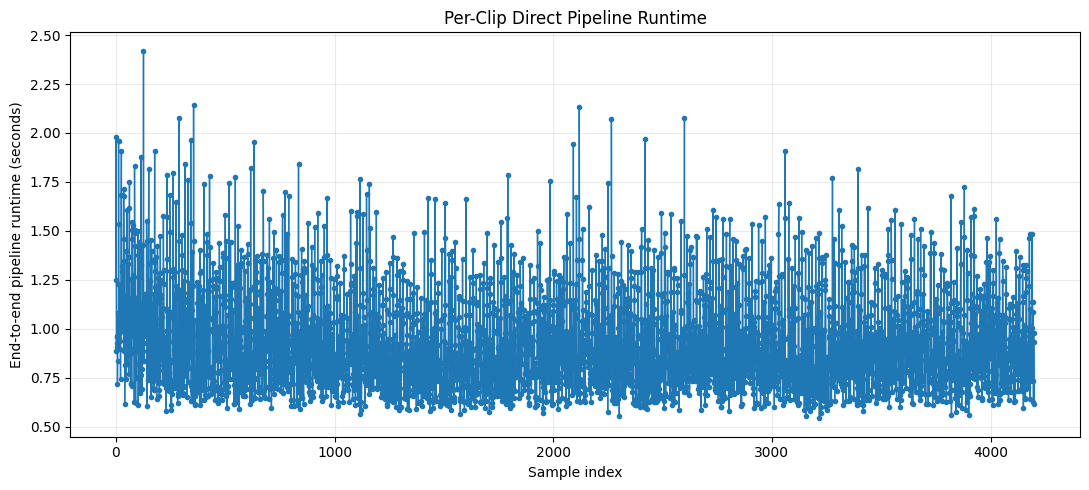

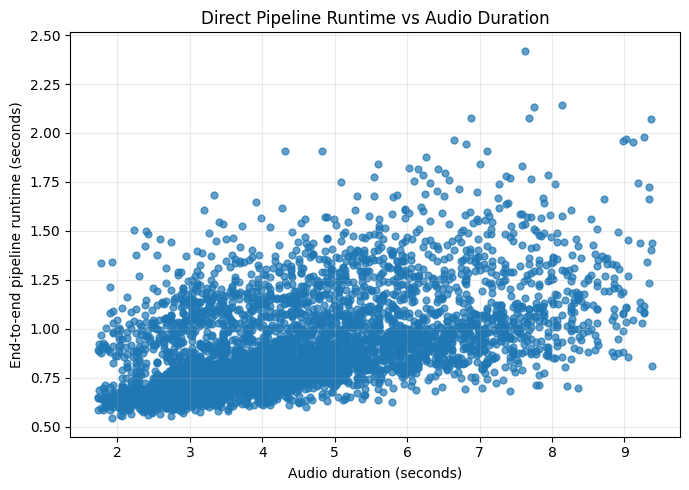

Saved runtime figure: /content/runs/direct_run_1788151795/runtime_per_clip.png
Saved duration figure: /content/runs/direct_run_1788151795/runtime_vs_audio_duration.png


In [20]:
plot_df = runtime_df.loc[success_mask].copy()
plot_df["sample_index"] = pd.to_numeric(plot_df["sample_index"], errors="coerce")
plot_df["direct_runtime_sec"] = pd.to_numeric(plot_df["direct_runtime_sec"], errors="coerce")
plot_df["audio_duration_sec"] = pd.to_numeric(plot_df["audio_duration_sec"], errors="coerce")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    plot_df["sample_index"],
    plot_df["direct_runtime_sec"],
    marker="o",
    markersize=3,
    linewidth=1,
)
ax.set(
    title="Per-Clip Direct Pipeline Runtime",
    xlabel="Sample index",
    ylabel="End-to-end pipeline runtime (seconds)",
)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RUNTIME_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

duration_plot_df = plot_df.dropna(subset=["audio_duration_sec", "direct_runtime_sec"])
if len(duration_plot_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        duration_plot_df["audio_duration_sec"],
        duration_plot_df["direct_runtime_sec"],
        alpha=0.7,
        s=24,
    )
    ax.set(
        title="Direct Pipeline Runtime vs Audio Duration",
        xlabel="Audio duration (seconds)",
        ylabel="End-to-end pipeline runtime (seconds)",
    )
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(DURATION_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()

print(f"Saved runtime figure: {RUNTIME_FIGURE_PATH.resolve()}")
if DURATION_FIGURE_PATH.exists():
    print(f"Saved duration figure: {DURATION_FIGURE_PATH.resolve()}")


# 19. Save Run Summary and Final Reproducibility Record

The run summary stores completion, runtime, generation diagnostics, resource usage, model revision, dataset fingerprints, and output paths.

The environment/config files are also updated with final peak-GPU-memory information.


In [21]:
environment_info.update({
    "peak_gpu_memory_allocated_gb": runtime_summary["peak_gpu_memory_allocated_gb"],
    "peak_gpu_memory_reserved_gb": runtime_summary["peak_gpu_memory_reserved_gb"],
})
ENVIRONMENT_PATH.write_text(json.dumps(environment_info, indent=2, ensure_ascii=False), encoding="utf-8")
CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

run_summary = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_started_utc": RUN_STARTED_UTC,
    "run_finished_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_mode": DATASET_MODE,
    "number_of_input_samples": len(metadata_df),

    "dataset_fingerprint": {
        "metadata_sha256": METADATA_SHA256_BEFORE,
        "ordered_id_sha256": ID_SHA256,
    },

    "model_id": MODEL_ID,
    "requested_model_revision": MODEL_REVISION,
    "resolved_model_revision": RESOLVED_MODEL_REVISION,
    "target_language": TARGET_LANGUAGE,
    "generation_settings": GENERATION_KWARGS,
    "decoding_policy_note": DECODING_POLICY_NOTE,

    "device": str(DEVICE),
    "gpu_name": GPU_NAME,
    "gpu_driver_version": GPU_DRIVER_VERSION,
    "git_commit": GIT_COMMIT,

    **runtime_summary,

    "output_files": {
        "predictions_csv": str(PREDICTIONS_PATH.resolve()),
        "runtime_csv": str(RUNTIME_PATH.resolve()),
        "environment_json": str(ENVIRONMENT_PATH.resolve()),
        "config_json": str(CONFIG_PATH.resolve()),
        "runtime_figure": str(RUNTIME_FIGURE_PATH.resolve()),
        "duration_figure": str(DURATION_FIGURE_PATH.resolve()) if DURATION_FIGURE_PATH.exists() else None,
    },
}

SUMMARY_PATH.write_text(json.dumps(run_summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved run summary: {SUMMARY_PATH.resolve()}")


Saved run summary: /content/runs/direct_run_1788151795/run_summary.json


# 20. Final Validation

This cell performs real integrity checks rather than symbolic assertions.

It verifies:

- prediction row/column integrity;
- exact source metadata preservation;
- source metadata SHA-256 unchanged from the start of the run;
- unique/non-missing `sample_id`;
- final 4,200 / 7 × 600 balance when `DATASET_MODE == "final"`;
- final audio completeness/uniqueness;
- translation/diagnostic consistency;
- required output files.

Generation-cap flags are reported separately as a warning because the flag is conservative and should be inspected rather than automatically treated as proof of truncation.


In [23]:
written_predictions = pd.read_csv(PREDICTIONS_PATH)
written_runtime = pd.read_csv(RUNTIME_PATH)
written_source_metadata = pd.read_csv(METADATA_PATH)

METADATA_SHA256_AFTER = sha256_file(METADATA_PATH)

final_balance_ok = True
final_audio_ok = True
if DATASET_MODE == "final":
    final_counts = written_source_metadata["primary_accent"].value_counts(dropna=False)
    final_balance_ok = (
        len(written_source_metadata) == EXPECTED_FINAL_SAMPLES
        and len(final_counts) == EXPECTED_FINAL_ACCENT_GROUPS
        and final_counts.eq(EXPECTED_FINAL_SAMPLES_PER_ACCENT).all()
    )
    final_audio_ok = bool(audio_exists.all() and duplicate_audio_count == 0)

success_indices = pd.to_numeric(
    written_runtime.loc[written_runtime["direct_status"].eq("success"), "sample_index"],
    errors="coerce",
).dropna().astype(int)

validation_checks = {
    "prediction_rows_match_input": (
        len(written_predictions) == len(metadata_df)
    ),

    "original_columns_preserved": all(
        c in written_predictions.columns
        for c in original_columns
    ),

    "original_column_order_preserved": (
        written_predictions.columns.tolist()[1:1 + len(original_columns)]
        == original_columns
    ),

    "only_direct_translation_appended": (
        written_predictions.columns.tolist()
        == EXPECTED_PREDICTION_COLUMNS
    ),

    "source_metadata_values_preserved": (
        written_predictions[original_columns]
        .equals(written_source_metadata[original_columns])
    ),

    "source_metadata_sha256_unchanged": (
        METADATA_SHA256_AFTER == METADATA_SHA256_BEFORE
    ),

    "id_nonmissing": (
        written_predictions["id"].notna().all()
        and written_predictions["id"]
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),

    "id_unique": written_predictions["id"].is_unique,

    "sample_id_nonmissing": (
        written_source_metadata["sample_id"].notna().all()
        and written_source_metadata["sample_id"]
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),

    "final_dataset_size_and_balance_valid": final_balance_ok,
    "final_audio_complete_and_unique": final_audio_ok,

    "runtime_csv_exists": RUNTIME_PATH.is_file(),

    "required_output_files_exist": all(
        p.is_file()
        for p in [
            PREDICTIONS_PATH,
            RUNTIME_PATH,
            ENVIRONMENT_PATH,
            CONFIG_PATH,
            SUMMARY_PATH,
            RUNTIME_FIGURE_PATH,
        ]
    ),

    "all_successes_have_translation": (
        written_predictions.loc[
            success_indices,
            "direct_translation"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),

    "failed_samples_have_diagnostics": (
        written_runtime.query(
            "direct_status == 'failed'"
        )["direct_error"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ),
}

validation_df = pd.Series(validation_checks, name="passed").to_frame()
display(validation_df)

if not all(validation_checks.values()):
    failed_checks = [name for name, passed in validation_checks.items() if not passed]
    raise AssertionError(f"Final validation failed: {failed_checks}")

limit_hit_count = int(
    written_runtime.loc[written_runtime["direct_status"].eq("success"), "generation_limit_reached"]
    .fillna(False)
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
    .sum()
)

if limit_hit_count:
    warnings.warn(
        f"{limit_hit_count} successful output(s) hit the conservative generation-limit flag. "
        "Inspect them before downstream evaluation."
    )
else:
    print("Generation-limit diagnostic: no flagged successful outputs ✓")

print(f"Metadata SHA-256 unchanged: {METADATA_SHA256_BEFORE == METADATA_SHA256_AFTER}")
print("Final validation passed: outputs are complete, reproducible, and structurally consistent.")


,passed
prediction_rows_match_input,True
original_columns_preserved,True
original_column_order_preserved,True
only_direct_translation_appended,True
source_metadata_values_preserved,True
source_metadata_sha256_unchanged,True
id_nonmissing,True
id_unique,True
sample_id_nonmissing,True
final_dataset_size_and_balance_valid,True


Generation-limit diagnostic: no flagged successful outputs ✓
Metadata SHA-256 unchanged: True
Final validation passed: outputs are complete, reproducible, and structurally consistent.


# 21. Final Run Summary

The final cell prints a compact handoff summary for the downstream evaluation notebooks. It reports dataset identity, exact model revision, completion status, end-to-end pipeline timing, model-generation timing, generation-cap diagnostics, and peak GPU memory.


In [24]:
def format_number(value, decimals=3):
    return "N/A" if value is None or pd.isna(value) else f"{value:.{decimals}f}"

print(f"Dataset mode: {DATASET_MODE.upper()}")
print(f"Model: {MODEL_ID}")
print(f"Resolved model revision: {RESOLVED_MODEL_REVISION}")
print(f"Target: Chinese ({TARGET_LANGUAGE})")
print(f"Device: {DEVICE}")
print(f"GPU: {GPU_NAME or 'N/A'}")
print(f"GPU driver: {GPU_DRIVER_VERSION or 'N/A'}")
print()

print(f"Samples: {runtime_summary['total_samples']:,}")
print(f"Successful: {runtime_summary['successful_samples']:,}")
print(f"Failed: {runtime_summary['failed_samples']:,}")
print(f"Generation-limit flags: {runtime_summary['generation_limit_hits']:,}")
print()

print(
    "Total end-to-end pipeline runtime: "
    f"{format_number(runtime_summary['total_pipeline_runtime_sec'])} sec"
)
print(
    "Mean end-to-end sec/clip: "
    f"{format_number(runtime_summary['mean_pipeline_runtime_sec'])}"
)
print(
    "Median end-to-end sec/clip: "
    f"{format_number(runtime_summary['median_pipeline_runtime_sec'])}"
)
print(
    "Mean model-generation sec/clip: "
    f"{format_number(runtime_summary['mean_generation_runtime_sec'])}"
)
print(f"Mean RTF: {format_number(runtime_summary['mean_realtime_factor'])}")
print(
    "Peak GPU memory allocated: "
    f"{format_number(runtime_summary['peak_gpu_memory_allocated_gb'])} GB"
)
print()

print(f"Metadata SHA-256: {METADATA_SHA256_BEFORE}")
print(f"id SHA-256: {ID_SHA256}")
print(f"Git commit: {GIT_COMMIT or 'N/A'}")
print()

print(f"Predictions: {PREDICTIONS_PATH.resolve()}")
print(f"Runtime details: {RUNTIME_PATH.resolve()}")
print(f"Environment: {ENVIRONMENT_PATH.resolve()}")
print(f"Run config: {CONFIG_PATH.resolve()}")
print(f"Run summary: {SUMMARY_PATH.resolve()}")
print(f"Figures: {RUNTIME_FIGURE_PATH.resolve()}")
print("\nRUN COMPLETED AND VALIDATED.")


Dataset mode: FINAL
Model: facebook/seamless-m4t-v2-large
Resolved model revision: 5f8cc790b19fc3f67a61c105133b20b34e3dcb76
Target: Chinese (cmn)
Device: cuda
GPU: Tesla T4
GPU driver: 580.82.07

Samples: 4,200
Successful: 4,200
Failed: 0
Generation-limit flags: 0

Total end-to-end pipeline runtime: 3898.567 sec
Mean end-to-end sec/clip: 0.928
Median end-to-end sec/clip: 0.878
Mean model-generation sec/clip: 0.898
Mean RTF: 0.220
Peak GPU memory allocated: 2.876 GB

Metadata SHA-256: 57fb7e6b62647d661cb887bdd279f1b4af57bbf1fca8e5ee741b5490136dcdba
id SHA-256: bf79323ce8acbf43a01d5dfb234b68b2e99fcb08d95671fd2bb2f9932c37f225
Git commit: N/A

Predictions: /content/runs/direct_run_1788151795/direct_predictions.csv
Runtime details: /content/runs/direct_run_1788151795/direct_runtime.csv
Environment: /content/runs/direct_run_1788151795/run_environment.json
Run config: /content/runs/direct_run_1788151795/run_config.json
Run summary: /content/runs/direct_run_1788151795/run_summary.json
Figures: